In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importing Dataset
jobs = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/End-to-End%20Apps/job-market-analysis/data/processed/jobs_cleaned.csv')

In [5]:
# Dataset info
jobs.info()
jobs.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        391 non-null    object
 1   company_name     391 non-null    object
 2   location         391 non-null    object
 3   experience       391 non-null    int64 
 4   salary           391 non-null    object
 5   skills           391 non-null    object
 6   posted_time      391 non-null    object
 7   job_description  391 non-null    object
 8   job_link         391 non-null    object
 9   source           391 non-null    object
dtypes: int64(1), object(9)
memory usage: 30.7+ KB


,experience
count,391.000000
mean,1.028133
std,1.394762
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,12.000000


# Feature Engineering

In [6]:
# Job Category
DA = ['analyst','analysis','analytics']
DS = ['scientist','science']
DE = ['big','data engineer','etl','spark','hadoop','pipeline']
AI = ['machine learning','ai','nlp','llm','deep learning','computer vision','ml','artificial intelligence']
category = np.where(jobs['job_title'].str.contains('|'.join(DA)),'Data Analyst',
                    np.where(jobs['job_title'].str.contains('|'.join(DS)),'Data Scientist',
                    np.where(jobs['job_title'].str.contains('|'.join(DE)),'Data Engineer',
                    np.where(jobs['job_title'].str.contains('|'.join(AI)),'AI Engineer','Other'))))
jobs.insert(0,'job_category',category)

# Experience Level
b = [0,2,4,6,float('inf')]
l = ['Fresher','Junior','Mid','Senior']
level =  pd.cut(jobs['experience'],bins=b,labels=l)
jobs.insert(5,'experience_level',level)
jobs['experience_level'] = jobs['experience_level'].astype(str)
jobs['experience_level'] = jobs['experience_level'].replace('nan', 'Not Disclosed')

# Salary Category
jobs['salary'] = jobs['salary'].str.replace('$','',regex=False)
sal = []
for val in jobs['salary']:
    if val!='competitive salary':
        s = val.split('-')
        k = [int(i) for i in s]
        avg = round(sum(k)/len(k))
        sal.append(avg)
    else:
        sal.append(np.nan)
b = [0,500000,1000000,float('inf')]
l = ['Low','Medium','High']
vals = pd.cut(sal,labels=l,bins=b)
jobs.insert(7,'salary_category',vals)
jobs['salary_category'] = jobs['salary_category'].astype(str)
jobs['salary_category'] = jobs['salary_category'].replace('nan', 'Not Disclosed')

# Skills Count
sc = [len(i)+1 for i in jobs['skills'].str.split()]
jobs.insert(9,'skill_count',sc)

#EDA

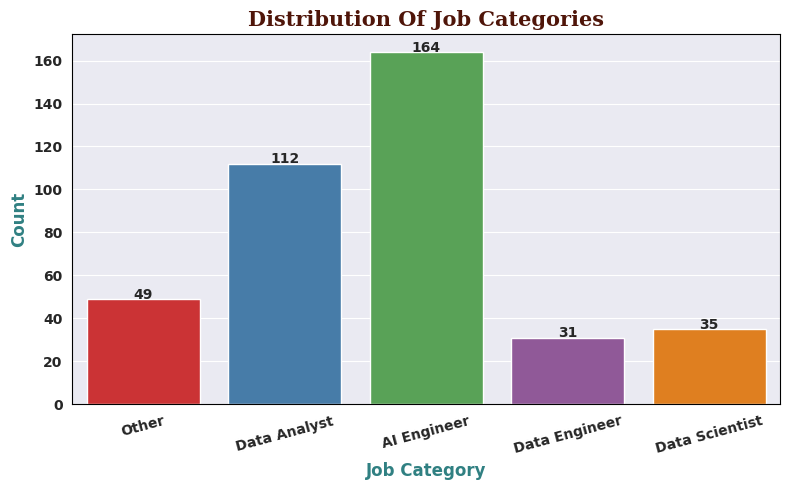

In [7]:
# Page Theme
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))

# Countplot
ax = sns.countplot(x='job_category',data=jobs,hue='job_category',palette='Set1')

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length>0:
        plt.text(i.get_x()+i.get_width()/2,length+2,round(length),ha='center',va='center',fontweight='bold',fontsize=10)

# Styling Title and Labels
plt.title('Distribution Of Job Categories',fontweight='bold',fontfamily='Serif',fontsize=15,color='#4F1509')
plt.xlabel('Job Category',fontweight='bold',fontsize=12,color='#308082')
plt.ylabel('Count',fontweight='bold',fontsize=12,color='#308082')
plt.xticks(rotation=15,fontweight='bold')
plt.yticks(fontweight='bold')
ax.spines[:].set_color('k')

# Page Layoout
plt.tight_layout()
plt.show()

# Insights:
# Most job openings are concentrated in one or two dominant categories,showing higher demand in those roles.
# Other categories have fewer openings, incidating more specialized or limited demand in the current job market

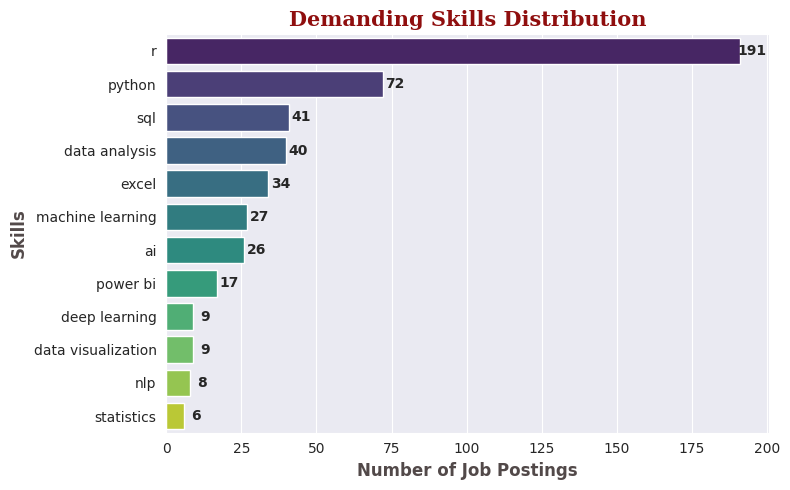

In [8]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Skills Counting
skills_list = ['python','r','sql','machine learning','deep learning','nlp','ai',
               'excel','power bi','statistics','data analysis','data visualization']
counts = []
for i in skills_list:
    tot = len(jobs[jobs['skills'].str.contains(i,case=False,na=False)])
    counts.append(tot)
sor = sorted(zip(skills_list,counts),key = lambda x : x[1],reverse=True)
sl , sc = zip(*sor)

# Barplot
ax = sns.barplot(x=sc,y=sl,hue=sl,palette='viridis')

# Annotation
for i in ax.patches:
    width = i.get_width()
    plt.text(width+4,i.get_y()+i.get_height()/2,round(width),ha='center',va='center',fontweight='bold')

# Styling Titles and Labels
plt.title('Demanding Skills Distribution',fontsize=15,fontweight='bold',fontfamily='Serif',color='#8F0E0E')
plt.xlabel('Number of Job Postings',fontsize=12,fontweight='bold',color='#524949')
plt.ylabel('Skills',fontsize=12,fontweight='bold',color='#524949')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# R,Python and SQL are among the most in-demand skills, followed by data analysis tools and machine learning.
# Indicates strong demand for both programming and analytical capabilities in job market.

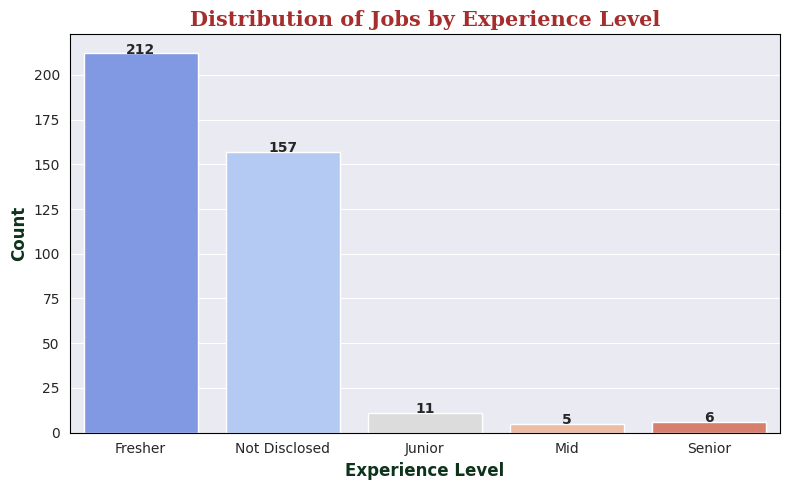

In [9]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Countplot
ax = sns.countplot(x='experience_level',data=jobs,hue='experience_level',palette='coolwarm',legend=False)

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length > 0 :
        plt.text(i.get_x()+i.get_width()/2,length+2,round(length),ha='center',va='center',fontweight='bold')

# Styling Title and Labels
plt.title('Distribution of Jobs by Experience Level',fontweight='bold',fontsize=15,fontfamily='Serif',color='#A62D2D')
plt.xlabel('Experience Level',fontweight='bold',fontsize=12,color='#0D331B')
plt.ylabel('Count',fontweight='bold',fontsize=12,color='#0D331B')
ax.spines[:].set_color('k')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Most job opportunities are concentrated in fresher and junior levels, showing strong demand for early-career professionals.
# Senior roles are fewer,more selective hiring for experienced candidates.

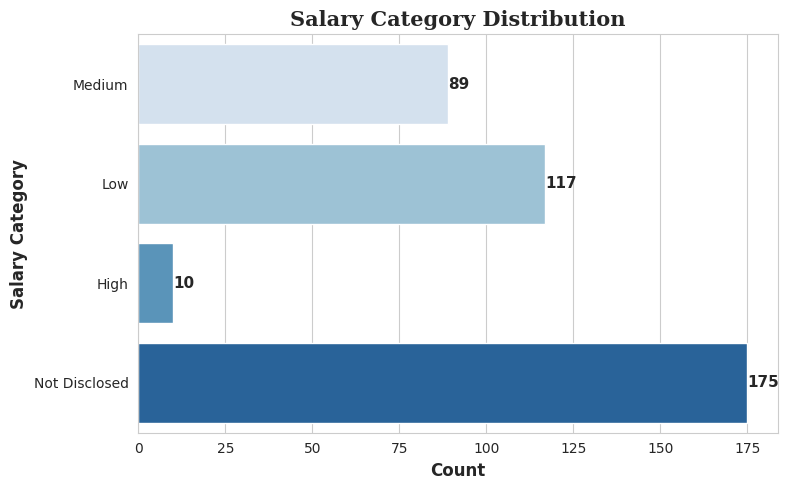

In [10]:
# Figoure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('whitegrid')

# Countplot
ax = sns.countplot(y='salary_category',data=jobs,hue='salary_category',palette='Blues',legend=False)

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0 :
        plt.text(width,i.get_y()+i.get_height()/2,round(width),ha='left',va='center',fontweight='bold',fontsize=11)

# Styling Titles and Labels
plt.title('Salary Category Distribution',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Count',fontsize=12,fontweight='bold')
plt.ylabel('Salary Category',fontsize=12,fontweight='bold')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Most job postings fall under low and medium salary categories, shows higher demand for low and midium roles.
# High salary jobs are relatively fewer, reflecting limited availability of top-paying positions.

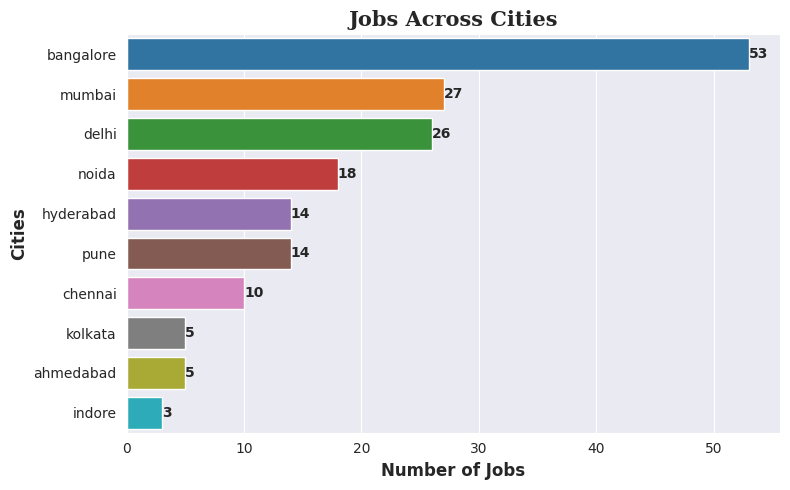

In [11]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Jobs Counting
city = ['bangalore','hyderabad','pune','chennai','delhi','mumbai','kolkata','noida','ahmedabad','indore']
count = []
for i in city:
    val = len(jobs[jobs['location'].str.contains(i,case=False)])
    count.append(val)
sor = sorted(zip(city,count),key = lambda x:x[1],reverse=True)
sl , sv = zip(*sor)

# Barplot
ax = sns.barplot(x=sv,y=sl,hue=sl)

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0:
        plt.text(width,i.get_y()+i.get_height()/2,round(width),ha='left',va='center',fontweight='bold')

# Styling Title and Labels
plt.title('Jobs Across Cities',fontsize=15,fontweight='bold',fontfamily='Serif')
plt.xlabel('Number of Jobs',fontsize=12,fontweight='bold')
plt.ylabel('Cities',fontsize=12,fontweight='bold')

# Page Layout
plt.tight_layout()
plt.show()

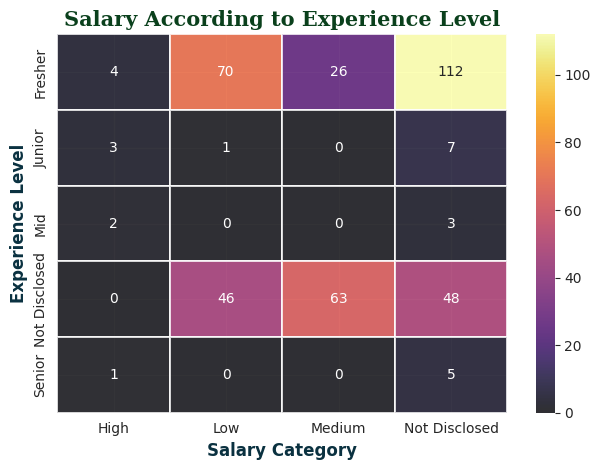

In [12]:
# Heatmap
sal_exp = pd.pivot_table(data=jobs,index='experience_level',columns='salary_category',values='job_category',aggfunc='count',observed=False)
sal_exp = sal_exp.fillna(0)
sns.heatmap(sal_exp,annot=True,cmap='inferno',linewidth=0.1,fmt='.0f',alpha=0.8)

# Styling Title and Labels
plt.title('Salary According to Experience Level',fontweight='bold',fontsize=15,fontfamily='Serif',color='#0A401C')
plt.xlabel('Salary Category',fontweight='bold',fontsize=12,color='#0A3140')
plt.ylabel('Experience Level',fontweight='bold',fontsize=12,color='#0A3140')

# Page Layout
plt.tight_layout()
plt.show()

# Insights
# Fresher roles are heavily concentrated low and not disclosed salary categories, indicating entry-level compensation structures.
# Experience increases,jobs shift toward higher salary ranges, while many senior roles have undisclosed salaries, suggesting flexible or negotiable pay.

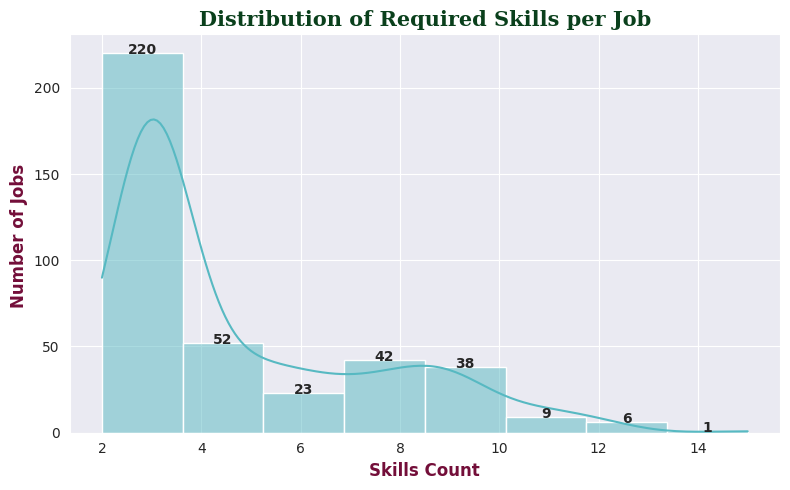

In [13]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Histplot
ax = sns.histplot(x='skill_count',data=jobs,bins=8,kde=True,color='#57B9C2')

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length > 0:
        plt.text(i.get_x()+i.get_width()/2,length+2,length,ha='center',va='center',fontweight='bold')

# Styling Title and Labels
plt.title('Distribution of Required Skills per Job',fontweight='bold',fontsize=15,fontfamily='Serif',color='#0A401C')
plt.xlabel('Skills Count',fontweight='bold',fontsize=12,color='#730E39')
plt.ylabel('Number of Jobs ',fontweight='bold',fontsize=12,color='#730E39')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Most job postings require around 3 to 5 skills, indicating a moderate skill demand in job market.
# Very few roles require a high number of skills, suggesting that highly specialized roles are less common.

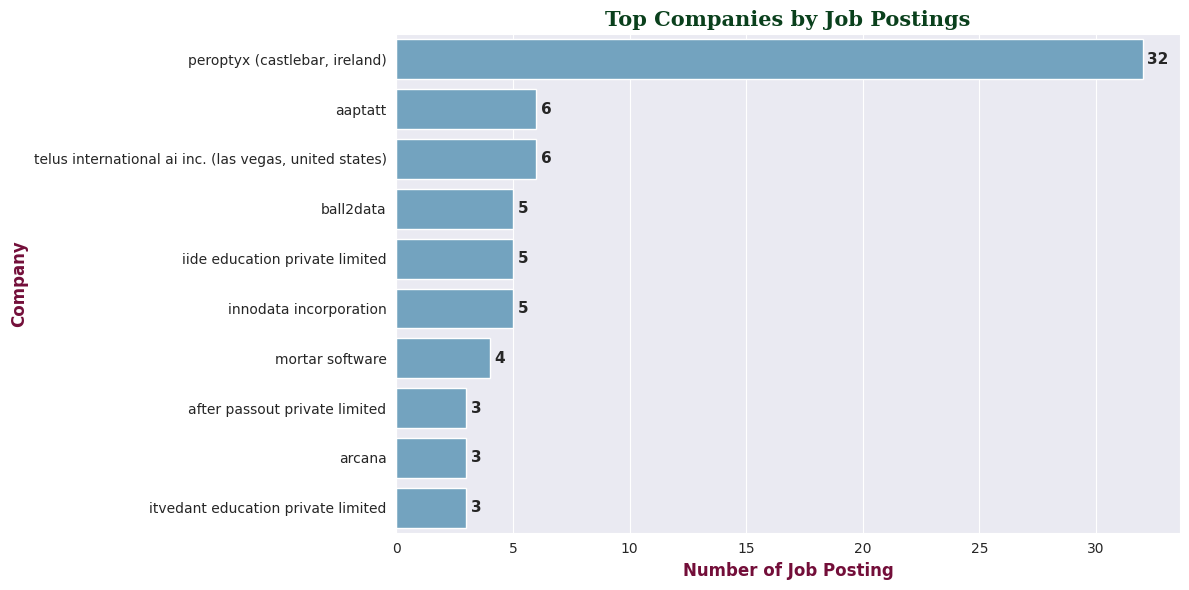

In [14]:
# Figure Size
plt.figure(figsize=(12,6))

# Page Theme
sns.set_style('darkgrid')

# Barplot
d = jobs.groupby('company_name')['job_category'].count().reset_index()
sor = sorted(zip(d['job_category'],d['company_name']),key=lambda x : x[0],reverse=True)[0:10]
sl,sv = zip(*sor)
ax = sns.barplot(x=sl,y=sv,color='#66A7CC')

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0 :
        plt.text(width+0.2,i.get_y()+i.get_height()/2,round(width),ha='left',va='center',fontweight='bold',fontsize=11)

# Styling Title and Labels
plt.title('Top Companies by Job Postings',fontweight='bold',fontsize=15,fontfamily='Serif',color='#0A401C')
plt.xlabel('Number of Job Posting',fontweight='bold',fontsize=12,color='#730E39')
plt.ylabel('Company',fontweight='bold',fontsize=12,color='#730E39')


# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Small number of companies account for large share of job postings,indicating concentrated hiring among key employers.
# Most companies have fewer postings, suggesting competitive and distributed job market.